/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 172.2763 - root_mean_squared_error: 13.0890 
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 62.6430 - root_mean_squared_error: 7.9123
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 29.7269 - root_mean_squared_error: 5.4448
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 17.9539 - root_mean_squared_error: 4.1788
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6.0707 - root_mean_squared_error: 2.4557
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.8043 - root_mean_squared_error: 1.6724
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1404 - root_mean_squared_error: 1.0598 
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7871 - root_mean_squared_error: 0.8687 
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7479 - root_mean_squared_error: 0.8565 
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0757 - root_mean_squared_error: 1.0341

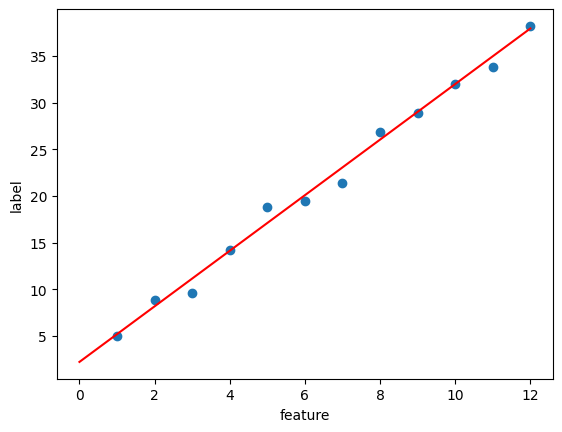

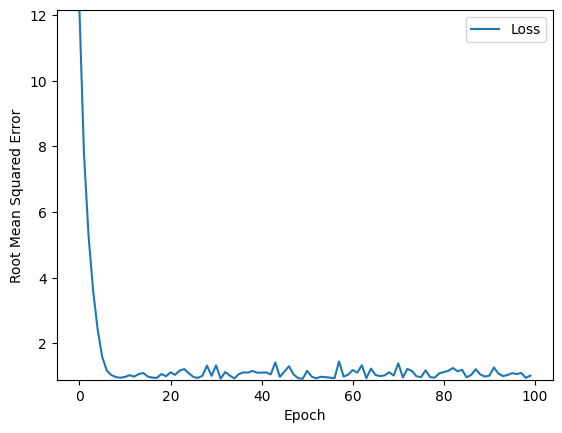

Веса модели: w = 2.9754, b = 2.2231
Финальная ошибка RMSE: 1.0197


In [ ]:
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import numpy as np

# 1.2. Построение модели
def build_model(rate):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(units=1, input_shape=(1,)))

    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=rate),
                 loss="mean_squared_error",
                 metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model

# Функция для обучения модели
def train_model(model, feature, label, epochs, batch_size):
    history = model.fit(x=feature,
                       y=label,
                       batch_size=batch_size,
                       epochs=epochs)

    trained_weight = model.get_weights()[0]
    trained_bias = model.get_weights()[1]

    epochs = history.epoch
    hist = pd.DataFrame(history.history)
    rmse = hist["root_mean_squared_error"]

    return trained_weight, trained_bias, epochs, rmse

# 1.3. Визуализация результатов обучения
def plot_the_model(trained_weight, trained_bias, feature, label):
    plt.xlabel("feature")
    plt.ylabel("label")
    plt.scatter(feature, label)

    # Модель линейной регрессии
    x0 = 0
    y0 = trained_bias
    x1 = feature[-1]
    y1 = trained_bias + (trained_weight * x1)
    plt.plot([x0, x1], [y0, y1], c='r')
    plt.show()

# Функция для визуализации процесса обучения
def plot_the_loss_curve(epochs, rmse):
    plt.figure()
    plt.xlabel("Epoch")
    plt.ylabel("Root Mean Squared Error")
    plt.plot(epochs, rmse, label="Loss")
    plt.legend()
    plt.ylim([rmse.min()*0.97, rmse.max()])
    plt.show()

# 1.4. Подготовка данных и обучение
# Исходные данные
features = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0])
labels = np.array([5.0, 8.8, 9.6, 14.2, 18.8, 19.5, 21.4, 26.8, 28.9, 32.0, 33.8, 38.2])

# Оптимальные параметры обучения
learning_rate = 0.1
epochs = 100
batch_size = 4

# Обучение модели
my_model = build_model(learning_rate)
trained_weight, trained_bias, epochs_history, rmse = train_model(my_model, features, labels, epochs, batch_size)

# Визуализация результатов
plot_the_model(trained_weight[0][0], trained_bias[0], features, labels)
plot_the_loss_curve(epochs_history, rmse)

# Анализ результатов
print(f"Веса модели: w = {trained_weight[0][0]:.4f}, b = {trained_bias[0]:.4f}")
print(f"Финальная ошибка RMSE: {rmse.values[-1]:.4f}")

In [ ]:
def get_region(x, y):

    a1 = y > x - 1   # выше линии y = x - 1
    a2 = y > x + 2   # выше линии y = x + 2
    a3 = y > -x + 5  # выше линии y = -x + 5
    a4 = y > -x - 2  # выше линии y = -x - 2

    if a1 and not a2 and a4 and not a3:
        return 9
    if not a1 and not a4:
        return 1
    elif not a1 and a3:
        return 3
    elif a2 and a3:
        return 5
    elif a2 and not a4:
        return 7
    elif not a1 and a4 and not a3:
        return 2
    elif a1 and not a2 and a3:
        return 6
    elif a1 and not a2 and not a4:
        return 8
    elif a2 and not a3 and a4:
        return 4
    return 9
x = float(input())
y = float(input())
print(get_region(x, y))




KeyboardInterrupt: Interrupted by user

In [ ]:
# Эталонные точки (x, y) для каждой из 9 областей
etalon_points = [
    (-2, -4),   # область 1
    (-1, -1),   # область 2
    (-2, 2),    # область 3
    (0, 4),     # область 4
    (3, 6),     # область 5
    (2, 4),     # область 6
    (4, -5),    # область 7
    (1, -1),    # область 8
    (0, 0),     # область 9
]

# Метки классов: от 1 до 9
labels = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])

# Преобразуем метки в one-hot кодировку (всего 9 классов)
# to_categorical ожидает метки от 0 до n_classes-1 → вычитаем 1
labels_onehot = to_categorical(labels - 1, num_classes=9)

# Вывод результатов
print("Эталонные точки (x, y):")
for i, point in enumerate(etalon_points):
    print(f"Точка {point} -> класс {labels[i]} -> one-hot: {labels_onehot[i]}")

print("\nМатрица one-hot кодов (9x9):")
print(labels_onehot)

NameError: name 'to_categorical' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


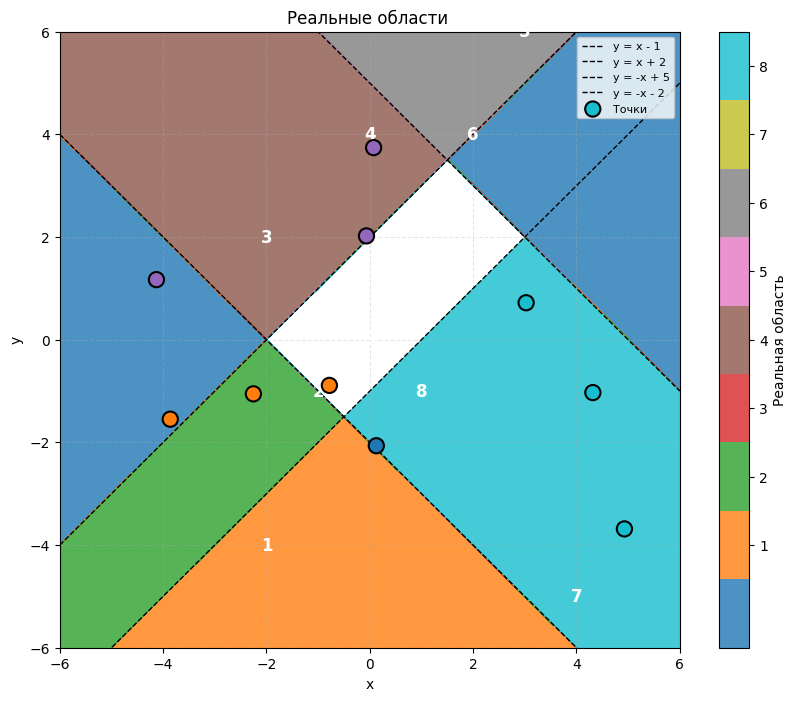

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Функция определения бинарного кода области по 4 прямым
def real_class(x, y):
    above1 = y > x - 1   # выше y = x - 1
    below2 = y < x + 2   # ниже y = x + 2
    below3 = y < -x + 5  # ниже y = -x + 5
    above4 = y > -x - 2  # выше y = -x - 2
    return (above1 << 3) | (below2 << 2) | (below3 << 1) | (above4 << 0)

#  контрольные точки для нумерации областей (1..9)
target_points = [
    (-2, -4),   # область 1
    (-1, -1),   # область 2
    (-2, 2),    # область 3
    (0, 4),     # область 4
    (3, 6),     # область 5
    (2, 4),     # область 6
    (4, -5),    # область 7
    (1, -1),    # область 8
    (0, 0),     # область 9
]


true_classes = {real_class(x, y): i+1 for i, (x, y) in enumerate(target_points)}
valid_codes = set(true_classes.keys())

# Генерируем сетку для реальных областей
xx, yy = np.meshgrid(np.linspace(-6, 6, 400), np.linspace(-6, 6, 400))
real_labels = np.zeros_like(xx, dtype=int)
for i in range(len(xx)):
    for j in range(len(yy)):
        cls = real_class(xx[i, j], yy[i, j])
        real_labels[i, j] = true_classes.get(cls, 0)  # невалидные → 0

# Генерируем обучающие данные — только из валидных областей
np.random.seed(42)
X_train = []
y_train = []

while len(X_train) < 1000:
    x, y = np.random.uniform(-4, 4, 2)
    cls = real_class(x, y)
    if cls in valid_codes:
        X_train.append([x, y])
        y_train.append(true_classes[cls] - 1)  # переводим 1..9 → 0..8

X_train = np.array(X_train)
y_train = np.array(y_train)

# Проверяем, что все метки в допустимом диапазоне
assert y_train.min() >= 0 and y_train.max() <= 8, "Недопустимые метки классов!"

# Модель: 2 входа → 4 нейрона → 9 выходов
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(9, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50, verbose=0)  # Теперь работает!

# 10 произвольных точек для проверки
X_test = np.random.uniform(-5, 5, (10, 2))
y_pred = np.argmax(model.predict(X_test), axis=1)

# Визуализация
plt.figure(figsize=(10, 8))

# Реальные области
cmap = plt.cm.tab10
contour = plt.contourf(xx, yy, real_labels, levels=np.arange(10)-0.5, cmap=cmap, alpha=0.8, zorder=0)

# Подписи областей 1–9
for (x, y), label in zip(target_points, range(1, 10)):
    plt.text(x, y, str(label), ha='center', va='center', fontsize=12, fontweight='bold', color='white', zorder=10)

# Прямые
x_line = np.linspace(-6, 6, 200)
plt.plot(x_line, x_line - 1, 'k--', lw=1, label='y = x - 1')
plt.plot(x_line, x_line + 2, 'k--', lw=1, label='y = x + 2')
plt.plot(x_line, -x_line + 5, 'k--', lw=1, label='y = -x + 5')
plt.plot(x_line, -x_line - 2, 'k--', lw=1, label='y = -x - 2')

# Точки
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap=cmap, s=120, edgecolor='k', linewidth=1.5, label='Точки', zorder=20)

plt.colorbar(contour, ticks=range(1,10), label="Реальная область")
plt.title("Реальные области ")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(loc='upper right', fontsize=8)
plt.xlim(-6, 6); plt.ylim(-6, 6)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()